# TLDR:
* Model: Davit
* PreProcessing: None
* Data: DE features
* Balancing Technique: Weighted random sampler
* Labels: 0 (Neutral) , 1  Negative (Sad), 2  (Fear) , 3 Positive (Happy)
* Test Accuracy: 

In [1]:
!pip install torcheeg==1.1.2 scipy==1.12.0 numpy==1.26.4 -qqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.5/214.5 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.1/295.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!git clone https://github.com/jiaowoguanren0615/DaViT-Pytorch DaViT

Cloning into 'DaViT'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 27 (delta 2), reused 18 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 30.26 KiB | 10.09 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torcheeg import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torcheeg.datasets import SEEDIVFeatureDataset
from DaViT.models.davit import DaViT
from sklearn.model_selection import train_test_split
from torchvision.transforms import RandomErasing

import time
import os
import shutil
import random

import numpy as np

from torcheeg.datasets.constants import SEED_IV_CHANNEL_LOCATION_DICT

# --- THE MAIN SUBJECT LOOP ---
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) 

In [6]:
# used for logging
TRIAL_NUMBER = 31

In [7]:
USE_GPU = 1
BATCH_SIZE = 64
DROPOUT = 0.5
ATTN_DROPOUT = 0.5
LR = 0.0005
WEIGHT_DECAY = 2e-1
EPOCHS_COUNT = 250
patience = 50

In [8]:
def map_emotions(y):
    # Input y is 0, 1, 2, or 3
    if y == 0: 
        return 0  # Neutral remains 0
    elif y == 1 or y == 2: 
        return 1  # Sad (1) and Fear (2) become Negative (1)
    elif y == 3: 
        return 2  # Happy (3) becomes Positive (2)
    return 0

In [9]:
class RemapLabel:
    def __call__(self, y):
        return {"y": map_emotions(y)}

In [10]:
# io_path = "/home/omar/external/python/eeg-emotion/tmp_out/seed_iv_feautres"
# root_path = "./SEED-IV/eeg_feature_smooth/"

io_path="./tmp_out/seed_iv_features"
root_path = "/kaggle/input/seed-iv/eeg_feature_smooth"

In [11]:
# 3. Load Data
dataset = SEEDIVFeatureDataset(
    # io_path=io_path,
    root_path=root_path,
    feature=["de_LDS"],
    num_worker=4,
    offline_transform=transforms.Compose(
        [
            transforms.BaselineRemoval(),
            transforms.To2d(),
            transforms.ToTensor(),
        ]
    ),
    label_transform=transforms.Compose(
        [
            transforms.Select("emotion"),
            # RemapLabel(),
        ]
    ),
    online_transform=transforms.Compose([transforms.MeanStdNormalize()]),
    io_mode="memory",
)

[2026-02-08 22:41:04] INFO (torcheeg/MainThread) 🔍 | Processing EEG data. Processed EEG data has been cached to .torcheeg/datasets_1770590464089_NbrnT.
[2026-02-08 22:41:04] INFO (torcheeg/MainThread) ⏳ | Monitoring the detailed processing of a record for debugging. The processing of other records will only be reported in percentage to keep it clean.
[PROCESS]:   0%|          | 0/45 [00:00<?, ?it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 0it [00:00, ?it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 1it [00:00,  3.53it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 836it [00:00, 2800.75it/s]
[PROCESS]: 100%|██████████| 45/45 [00:11<00:00,  3.93it/s]


In [12]:
# 1. Get the metadata DataFrame
df = dataset.info

# 2. Count the segments for each emotion
# 0: Neutral, 1: Sad, 2: Fear, 3: Happy
counts = df["emotion"].value_counts().sort_index()
total = len(df)

print(f"Total Segments: {total}")
print("-" * 30)
print("Count per Emotion:")
print(counts)

print("-" * 30)
print("Percentage per Emotion:")
percentages = (counts / total) * 100
print(percentages.round(2))

# 3. Check for Imbalance
# If the difference between max and min is > 10%, we might need a WeightedSampler
max_pct = percentages.max()
min_pct = percentages.min()

if (max_pct - min_pct) > 10:
    print(f"\n⚠️ WARNING: Data is IMBALANCED (Diff: {max_pct - min_pct:.2f}%)")
    print("Consider using a WeightedRandomSampler.")
else:
    print(f"\n✅ Data is reasonably BALANCED (Diff: {max_pct - min_pct:.2f}%)")

Total Segments: 37575
------------------------------
Count per Emotion:
emotion
0    10170
1    10245
2     9225
3     7935
Name: count, dtype: int64
------------------------------
Percentage per Emotion:
emotion
0    27.07
1    27.27
2    24.55
3    21.12
Name: count, dtype: float64

✅ Data is reasonably BALANCED (Diff: 6.15%)


In [13]:
# 4. Check Data Shape & Setup Model
# We fetch one sample to determine input channels and dimensions
# (using the whole dataset for detection is fine as shape is consistent)
temp_loader = DataLoader(dataset, batch_size=1, shuffle=False)
temp_X, _ = next(iter(temp_loader))
input_channels = temp_X.shape[1]
print(f"Detected Input Shape: {temp_X.shape}")
print(f"Setting model in_chans to: {input_channels}")

Detected Input Shape: torch.Size([1, 1, 62, 5])
Setting model in_chans to: 1


In [14]:
def DaViT_eeg(
    pretrained=False, pretrained_cfg=None, pretrained_cfg_overlay=None, **kwargs
):
    model_kwargs = dict(
        patch_size=4,
        in_chans=input_channels,
        window_size=3,
        # Restoring "Tiny" dimensions (User has VRAM headroom)
        # embed_dims=(96, 192, 384, 768),
        # num_heads=(3, 6, 12, 24),
        embed_dims=(64, 128, 256, 512),
        num_heads=(2, 4, 8, 16),
        depths=(1, 1, 1, 1),
        mlp_ratio=4.0,
        overlapped_patch=False,
        num_classes=4,
        drop_rate=kwargs.get("dropout", 0.5),
        attn_drop_rate=kwargs.get("attn_dropout", 0.5),
        drop_path_rate=0.3, # Add Stochastic Depth
        **kwargs,
    )

    return DaViT(**model_kwargs)

# model = DaViT_eeg(dropout=dropout, attn_dropout=attn_dropout).to(device)


In [15]:
subjects = sorted(dataset.info["subject_id"].unique())  # Get list of all 15 subjects

In [16]:
# --- MIXUP HELPER FUNCTIONS ---
def mixup_data(x, y, alpha=1.0):
    """
    Applies Mixup augmentation to a batch of data.
    
    Logic:
    1. Generate a mixing coefficient (lambda) from a Beta(alpha, alpha) distribution.
       - If alpha is close to 0, lambda is close to 0 or 1 (little mixing).
       - If alpha is large, lambda is close to 0.5 (strong mixing).
    2. Shuffle the batch indices to get a "partner" for every sample.
    3. Create a new "mixed" input: mixed_x = lambda * x + (1 - lambda) * x[shuffled_indices]
    
    Returns:
        mixed_x: The blended input tensor.
        y_a: The original labels.
        y_b: The labels of the shuffled samples.
        lam: The mixing coefficient used.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Calculates the Mixup loss.
    
    Since the input was a mix of two samples (A and B) with weight lambda:
    Loss = lambda * Loss(pred, Label_A) + (1 - lambda) * Loss(pred, Label_B)
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [17]:
all_subject_accuracies = []
all_subject_histories = {}
for subject_id in subjects:
    print("\n========================================")
    print(f"  PROCESSING SUBJECT: {subject_id}")
    print("========================================")

    # 1. Filter Data for this Subject
    sub_df = dataset.info[dataset.info["subject_id"] == subject_id]

    # 2. Split by Unique Video (Session + Trial) for this subject
    # CRITICAL: We cannot just split by 'trial_id' because Trial 1 in Session 1 (Sad)
    # is different from Trial 1 in Session 2 (Fear). We must treat them as separate videos.

    # Create a unique ID for every video: "session_trial" (e.g., "1_5", "2_5", "3_5")
    sub_df = sub_df.copy()  # Avoid SettingWithCopy warning
    sub_df["unique_run_id"] = (
        sub_df["session_id"].astype(str) + "_" + sub_df["trial_id"].astype(str)
    )

    # Extract labels per unique run to ensure balanced split
    # We get a single label for each unique run (session_trial)
    # Since every segment in a trial has same label, we just drop duplicates
    run_info = sub_df[["unique_run_id", "emotion"]].drop_duplicates()
    all_runs = run_info["unique_run_id"].values
    all_labels = run_info["emotion"].values

    # Stratified Split at the RUN level
    # This keeps 80/20 ratio and ensures each class is represented in the test set
    train_runs, test_runs = train_test_split(
        all_runs, test_size=0.20, random_state=42, stratify=all_labels
    )

    print(f"Total Unique Videos (Across 3 Sessions): {len(all_runs)}")
    print(f"Training on: {len(train_runs)} | Testing on: {len(test_runs)}")

    # Extract indices (Zero Leakage Guaranteed)
    train_indices = sub_df[sub_df["unique_run_id"].isin(train_runs)].index.tolist()
    test_indices = sub_df[sub_df["unique_run_id"].isin(test_runs)].index.tolist()

    train_set = Subset(dataset, train_indices)
    test_set = Subset(dataset, test_indices)

    y_train_indices = train_set.indices
    raw_labels = dataset.info.iloc[y_train_indices]["emotion"].values

    # 3. Create Specific Sampler for this Subject
    class_counts = np.bincount(raw_labels)
    class_weights = 1.0 / class_counts
    print(class_weights)
    sample_weights = [class_weights[y] for y in raw_labels]

    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    # 4. Loaders
    train_loader = DataLoader(
        train_set, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0
    )
    test_loader = DataLoader(
        test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    train_count = len(train_loader)
    test_count = len(test_loader)

    # 5. FRESH Model & Optimizer (Reset for every subject)
    model = DaViT_eeg(dropout=DROPOUT, attn_dropout=ATTN_DROPOUT, _num_classes=len(class_weights)).to(
        device
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Cosine Annealing: Smoothly drops LR from 0.0001 -> 0 over EPOCHS_COUNT
    # This forces the model to settle into the best accuracy at the end
    # scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_COUNT, eta_min=1e-6)

    # OneCycleLR is better for transformers (Warmup + Annealing)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=LR,
        epochs=EPOCHS_COUNT,
        steps_per_epoch=len(train_loader),
        pct_start=0.3,  # 30% warmup
        div_factor=10,
        final_div_factor=1000,
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights).to(device).float(), label_smoothing=0.1
    )
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # 6. Training Loop for this Subject
    best_acc = 0.0
    best_loss = float('inf')
    counter = 0        

    subject_train_acc = []
    subject_val_acc = []
    prinT = 0

    # Initialize Random Erasing
    # p=0.5: 50% chance to apply
    # scale=(0.02, 0.25): Erase smaller chunks to avoid killing too much info
    # ratio=(0.05, 20.0):
    #   - 0.05 means aspect ratio 1:20 (Very wide/flat, erasing a specific band across many channels)
    #   - 20.0 means aspect ratio 20:1 (Very tall/thin, erasing all bands for a few channels)
    # This flexibility suits the 62x5 shape much better than the default (0.3, 3.3).
    eraser = RandomErasing(
        p=0.5, scale=(0.02, 0.25), ratio=(0.05, 20.0), value=0, inplace=False
    )
    
    # --- MAIN LOOP EXTENSION ---
    for epoch in range(EPOCHS_COUNT):  # 40 epochs is usually enough for 1 subject
        startTime = time.time()
        model.train()
        train_loss = 0
        correct = 0
        total = 0



        for batch in train_loader:
            X, y = batch
            # 1. Augmentation: Add Gaussian Noise
            noise = torch.randn_like(X) * 0.05  # 5% noise factor
            X = X + noise

            # 2. Augmentation: Random Erasing
            # Random Erasing expects (B, C, H, W).
            X = eraser(X)

            if prinT:
                print(f"X: {X.shape},y: {y.shape}")
                prinT = 0

            X = X.to(device)
            y = y.to(device).long()

            # 2. Apply Mixup
            X, y_a, y_b, lam = mixup_data(X, y, alpha=0.2)
            X, y_a, y_b = map(torch.autograd.Variable, (X, y_a, y_b))

            optimizer.zero_grad()
            outputs = model(X)

            # 3. Use Mixup Loss
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            optimizer.step()

            # For accuracy, we just compare against the dominant label (or y_a)
            # Mixup creates "soft" accuracy, but standard accuracy is fine for logging
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (
                lam * predicted.eq(y_a.data).cpu().sum().float()
                + (1 - lam) * predicted.eq(y_b.data).cpu().sum().float()
            ).item()
            # scheduler step for OneCycleLR is per batch
            scheduler.step()
            train_loss += loss.item()

        train_acc = (correct / total) * 100
        avg_train_loss = train_loss / train_count

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch

                X = X.to(device)
                y = y.to(device).long()

                output = model(X)

                loss = criterion(output, y)
                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += y.size(0)
                val_correct += (predicted == y).sum().item()

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / test_count
        current_lr = optimizer.param_groups[0]["lr"]
        elabsedTime = time.time() - startTime
        loss_ratio = avg_train_loss / avg_val_loss
        subject_train_acc.append(train_acc)
        subject_val_acc.append(val_acc)            

        # Early Stopping check (Monitor Validation Loss)
        is_best_acc = False
        if val_acc > best_acc:
            is_best_acc = True
            best_acc = val_acc
        
        # Monitor Loss for Early Stopping (No Model Saving)
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            counter = 0
        else:
            counter += 1
            # if counter >= patience:
            #     break

        print(
            f"Epoch {epoch + 1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}% | Loss: {avg_train_loss:.4f}/{avg_val_loss:.4f} | Loss Ratio: {loss_ratio:.2f} | LR: {current_lr:.6f} | Elapsed Time: {elabsedTime:.2f} seconds {'[BEST ACC]' if is_best_acc else ''}"
        )

    all_subject_accuracies.append(best_acc)
    all_subject_histories[subject_id] = {
        "train": subject_train_acc,
        "val": subject_val_acc,
    }


  PROCESSING SUBJECT: 1
Total Unique Videos (Across 3 Sessions): 72
Training on: 57 | Testing on: 15
[0.00195695 0.00175439 0.00220751 0.00257069]
Epoch 1: Train Acc=24.71% | Val Acc=24.05% | Loss: 1.4900/1.3772 | Loss Ratio: 1.08 | LR: 0.000050 | Elapsed Time: 2.69 seconds [BEST ACC]
Epoch 2: Train Acc=26.49% | Val Acc=24.05% | Loss: 1.3934/1.4019 | Loss Ratio: 0.99 | LR: 0.000051 | Elapsed Time: 1.77 seconds 
Epoch 3: Train Acc=31.79% | Val Acc=37.46% | Loss: 1.3704/1.3414 | Loss Ratio: 1.02 | LR: 0.000052 | Elapsed Time: 1.81 seconds [BEST ACC]
Epoch 4: Train Acc=33.22% | Val Acc=46.05% | Loss: 1.3472/1.3113 | Loss Ratio: 1.03 | LR: 0.000053 | Elapsed Time: 1.79 seconds [BEST ACC]
Epoch 5: Train Acc=40.98% | Val Acc=34.88% | Loss: 1.2528/1.2403 | Loss Ratio: 1.01 | LR: 0.000055 | Elapsed Time: 1.82 seconds 
Epoch 6: Train Acc=49.63% | Val Acc=41.92% | Loss: 1.1986/1.2203 | Loss Ratio: 0.98 | LR: 0.000057 | Elapsed Time: 1.82 seconds 
Epoch 7: Train Acc=50.43% | Val Acc=42.78% | Los

In [18]:
# --- FINAL RESULTS ---
avg_acc = sum(all_subject_accuracies) / len(all_subject_accuracies)
print(f"\n========================================")
print(f"FINAL AVERAGE ACCURACY: {avg_acc:.2f}%")
print(f"Detailed: {all_subject_accuracies}")
print(f"========================================")


FINAL AVERAGE ACCURACY: 85.02%
Detailed: [90.72164948453609, 95.36082474226804, 85.56701030927834, 92.78350515463917, 96.21993127147766, 83.67697594501718, 100.0, 92.78350515463917, 84.36426116838489, 89.86254295532646, 58.59106529209622, 59.106529209621996, 77.14776632302406, 74.5704467353952, 94.50171821305842]


Saved subject_accuracies.png


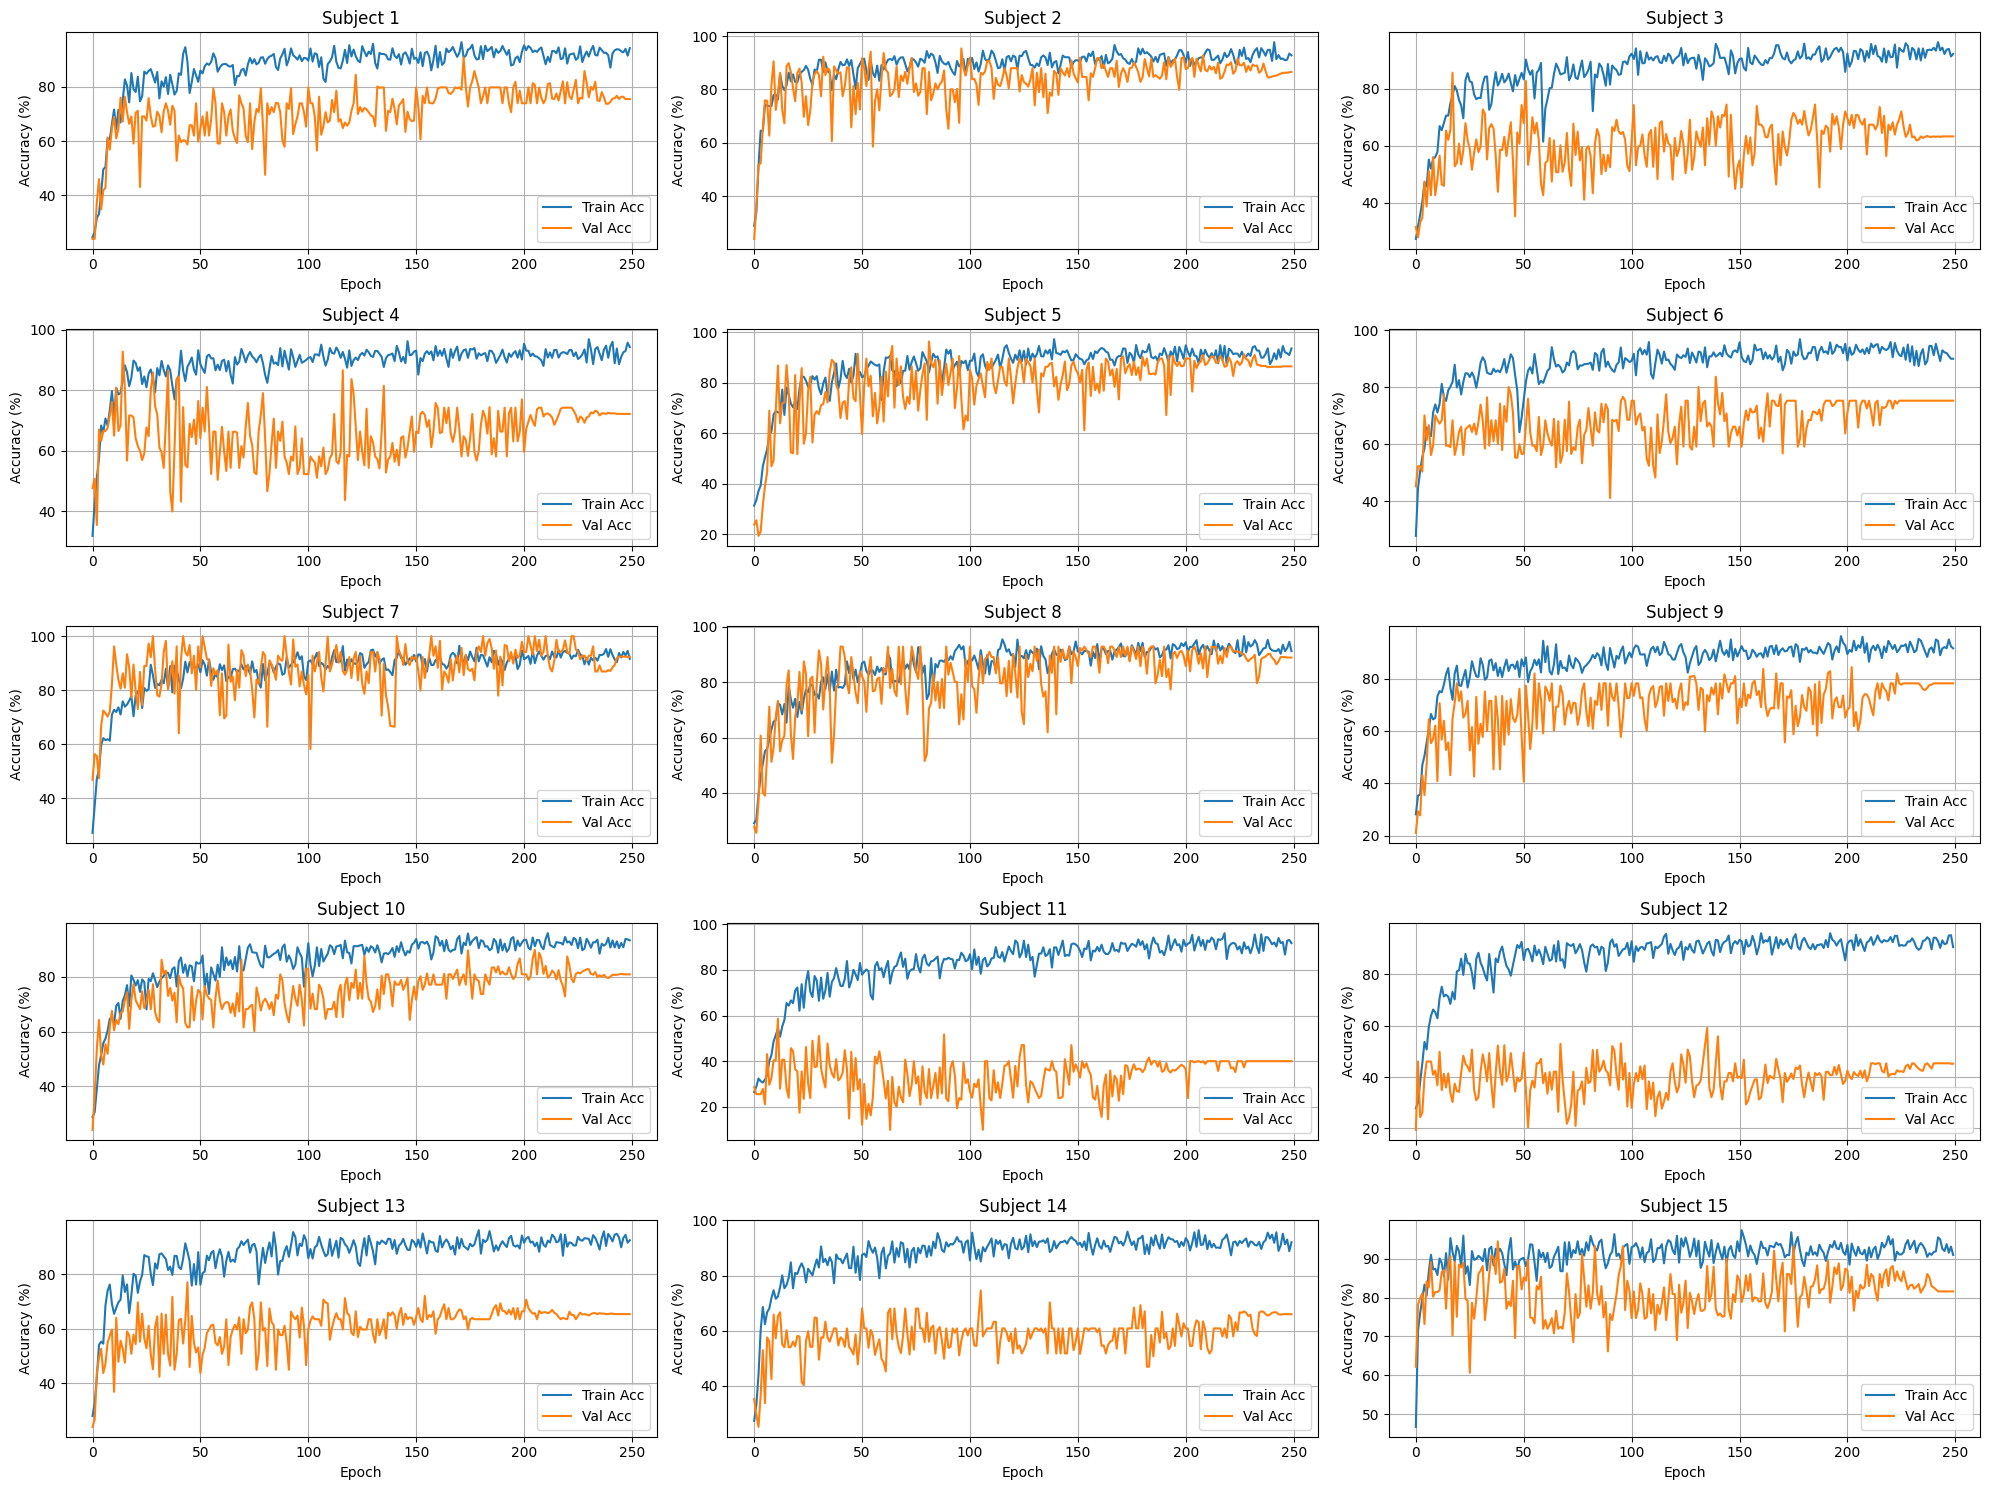

In [19]:
# --- PLOTTING ---
# 1. 5x3 Grid for individual subjects
fig, axes = plt.subplots(5, 3, figsize=(20, 15))
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    if i < len(axes):
        ax = axes[i]
        if subject_id in all_subject_histories:
            h = all_subject_histories[subject_id]
            ax.plot(h["train"], label="Train Acc")
            ax.plot(h["val"], label="Val Acc")
            ax.set_title(f"Subject {subject_id}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy (%)")
            ax.legend()
            ax.grid(True)

plt.tight_layout()
plt.savefig("subject_accuracies.png")
print("Saved subject_accuracies.png")
plt.show()

Saved average_accuracy.png


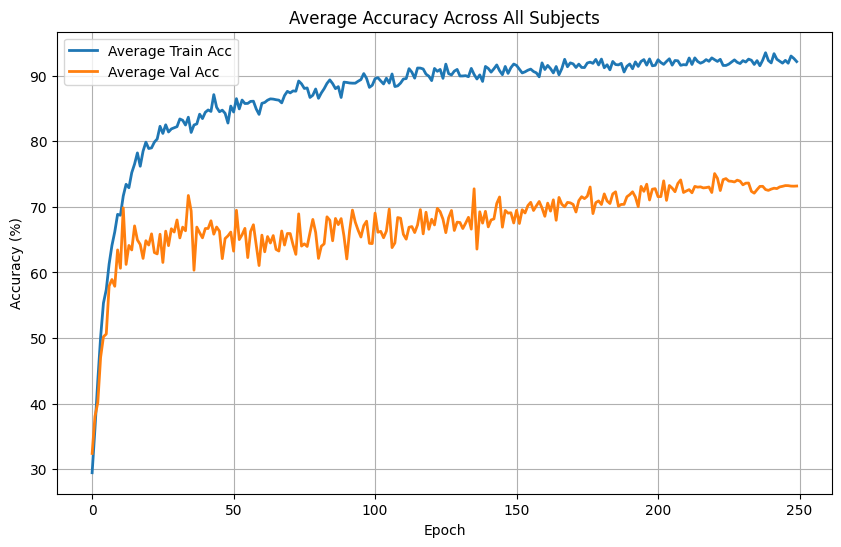

In [20]:
# 2. Average Plot
plt.figure(figsize=(10, 6))

# Find max epochs across all runs
max_epochs = 0
for h in all_subject_histories.values():
    max_epochs = max(max_epochs, len(h["train"]))

avg_train = []
avg_val = []

for e in range(max_epochs):
    t_vals = []
    v_vals = []
    for h in all_subject_histories.values():
        # Use last value if a subject finished early
        idx = min(e, len(h["train"]) - 1)
        t_vals.append(h["train"][idx])
        v_vals.append(h["val"][idx])

    avg_train.append(np.mean(t_vals))
    avg_val.append(np.mean(v_vals))

plt.plot(avg_train, label="Average Train Acc", linewidth=2)
plt.plot(avg_val, label="Average Val Acc", linewidth=2)
plt.title("Average Accuracy Across All Subjects")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.savefig("average_accuracy.png")
print("Saved average_accuracy.png")
plt.show()